# MMML Lab Assignment 4: HMM & Linear Dynamical Systems + Generative Modeling

The aim of this lab assigment is to feel in practice the generative modeling.

### Instructions 

1.   Form a team of up to two students.
2.   Rename the ipynb file to `Name1_Name2_MMML_Lab4.ipynb`.
3.   Indicate team members at the top.
4.   Provide your solutions (code or explanation) as necessary; do not reshuffle the cell order! You are welcome to optimize the existing commands if you want.
5.   Please execute all the cells before submission; make sure there are no errors, all plots have been generated, and all numerical answers calculated. Also, do not make *looong* prints.
6.   Submit your notebook to **LMS** in `.ipynb` format.


### Import needed libraries

In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [2]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

Generative modeling imports:

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.optimizer import Optimizer
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim
from torchvision.utils import make_grid

from dataclasses import dataclass
from abc import ABC, abstractmethod
from typing import override

import pickle
from typing import Tuple


## 1. Diffusion models **(4 pt)**


Diffusion models are a class of generative models that learn to generate data by reversing a gradual noising process. The key idea is the following:

- We start with a real data sample $x_0 \sim p_{\text{data}}(x)$.
- We gradually add Gaussian noise to it over $T$ steps until it becomes pure noise.
- We then train a neural network to reverse this process and recover data from noise.

Thus, generation is performed by starting from random noise and iteratively denoising it.

The dataset used in this task is [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html).

Useful video about diffusion models: https://www.youtube.com/watch?v=EhndHhIvWWw.

### 1.1. Data loading (0.25)

In [4]:
DATASET = "cifar10"

In [5]:
image_size = 32
channels = 3
num_classes = 10
tfm = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),  # map to ~[-1,1]
])
train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)

/datasets/maksymz/mmml-lab-4/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Now, you need to choose the optimal batch size. Justify your choise.

___
We have used batch size $128$ as it is standard size used in other implementations. Otherwise, we can say that batch size must be as big as we can get on the GPU.
___

In [6]:
# ========= YOUR CODE STARTS HERE ========= #
batch_size = 128
train_dl = DataLoader(train_ds,
                      batch_size=batch_size,
                      shuffle=True,
                      num_workers=8,
                      drop_last=True,
                      pin_memory=True, 
                      persistent_workers=True
                    )

# ========== YOUR CODE ENDS HERE ========== #
x0, y0 = next(iter(train_dl))
x0.shape, y0.shape

(torch.Size([128, 3, 32, 32]), torch.Size([128]))

Here is quick vizualization helper:

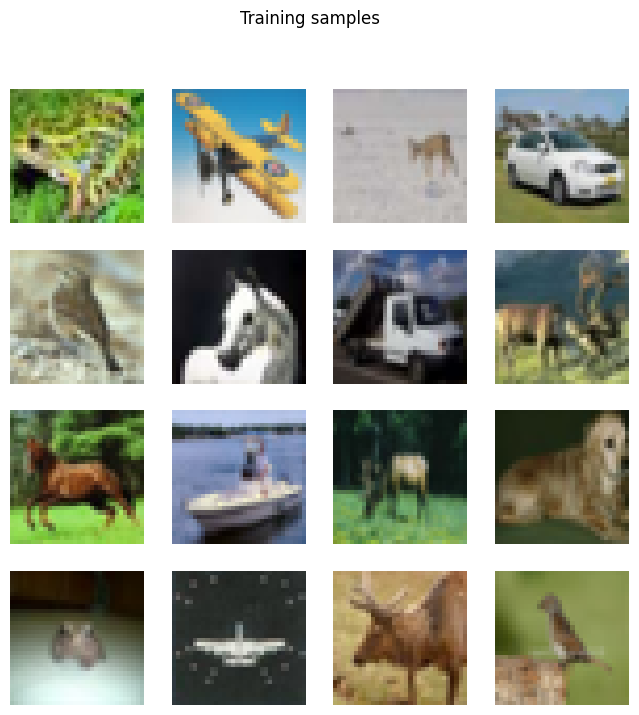

In [7]:
@torch.no_grad()
def show_batch(x, n=16, title=""):
    x = x[:n].detach().cpu()
    x = (x * 0.5 + 0.5).clamp(0,1)  # back to [0,1]
    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(cols*2, rows*2))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        img = x[i]
        if img.shape[0] == 1:
            plt.imshow(img[0], cmap="gray")
        else:
            plt.imshow(img.permute(1,2,0))
        plt.axis("off")
    plt.suptitle(title)
    plt.show()


@torch.no_grad()
def show_two_batches(x1, x2, n=16, title1="Batch 1", title2="Batch 2", main_title=""):
    x1 = x1[:n].detach().cpu()
    x2 = x2[:n].detach().cpu()
    x1 = (x1 * 0.5 + 0.5).clamp(0, 1)
    x2 = (x2 * 0.5 + 0.5).clamp(0, 1)
    
    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    
    fig = plt.figure(figsize=(cols * 4 + 1, rows * 2))
    
    widths = [1] * cols + [0.3] + [1] * cols
    gs = fig.add_gridspec(rows, cols * 2 + 1, width_ratios=widths)
    
    ax_b1 = fig.add_subplot(gs[:, :cols])
    ax_b1.axis("off")
    ax_b1.set_title(title1, fontsize=14, pad=20)
    
    ax_b2 = fig.add_subplot(gs[:, cols+1:])
    ax_b2.axis("off")
    ax_b2.set_title(title2, fontsize=14, pad=20)
    
    for i in range(n):
        row_idx = i // cols
        col_idx = i % cols
        
        ax1 = fig.add_subplot(gs[row_idx, col_idx])
        img1 = x1[i]
        if img1.shape[0] == 1:
            ax1.imshow(img1[0], cmap="gray")
        else:
            ax1.imshow(img1.permute(1, 2, 0))
        ax1.axis("off")
        
        ax2 = fig.add_subplot(gs[row_idx, col_idx + cols + 1])
        img2 = x2[i]
        if img2.shape[0] == 1:
            ax2.imshow(img2[0], cmap="gray")
        else:
            ax2.imshow(img2.permute(1, 2, 0))
        ax2.axis("off")
        
    if main_title:
        plt.suptitle(main_title, fontsize=18)
        
    plt.tight_layout()
    plt.show()


show_batch(x0, title="Training samples")

###  1.2. Forward diffusion process (1 pt)

The forward process (also called the \textit{noising process}) is defined as a Markov chain:
$$
q(x_{1:T} \mid x_0) = \prod_{t=1}^{T} q(x_t \mid x_{t-1}),
$$
where each transition adds a small amount of Gaussian noise:
$$
q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(x_t;\sqrt{\alpha_t}\,x_{t-1},\ (1-\alpha_t)I\right).
$$

Here:
- $\beta_t \in (0,1)$ is the noise variance at step $t$,
- $\alpha_t = 1 - \beta_t$ controls how much signal is preserved.

Over many steps, this process gradually destroys structure in the data. For large $T$, we have:
$$
x_T \approx \mathcal{N}(0, I).
$$

Now, you need to implement two different schedules: linear and cosine.

Explain the difference between them.

___

Noise schedules is basically sequence $\beta_t$ that sets added noise variance on step $t$. Most popular choices for $\beta_t$ are:

- **Linear**: 
$$\beta_t = \beta_{min} + \frac{t-1}{T-1}(\beta_{max} - \beta_{min})$$

- **Cosine**:
$$\overline{\alpha_t} = cos^2\left( \frac{t/T + s}{1 + s} \frac{\pi}{2}\right)$$

Main difference is that cosine schedule adds noise more gradually, while cosine linear adds a lot at the first iterations, but less and last.
___

In [8]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    # ========= YOUR CODE STARTS HERE ========= #
    # Return betas: shape [T], float32 torch tensor
    T = torch.arange(1, T+1)
    betas = beta_start + (T - 1) / (T[-1] - 1) * (beta_end - beta_start)
    return betas
    # ========== YOUR CODE ENDS HERE ========== #

In [ ]:
def beta(t, T, s):
    return (np.cos((t / T + s) / (1 + s) * np.pi / 2)) ** 2

def cosine_beta_schedule(T, s=0.008):

    
    alphas = []
    f0 = beta(0, T, s)

    for t in range(T + 1):
        alphas.append(beta(t, T, s) / f0)
    
    betas = []

    for t in range(1, T + 1):
        betas.append(min(1 - alphas[t] / alphas[t - 1], 0.999))
    
    return torch.from_numpy(np.array(betas)).to(torch.float32)
    # ========== YOUR CODE ENDS HERE ========== #

Now, write code for diffusion:

In [10]:
class Diffusion:
    def __init__(self, T=1000, schedule="cosine"):
        self.T = T
        betas = linear_beta_schedule(T) if schedule == "linear" else cosine_beta_schedule(T)

        # ========= YOUR CODE STARTS HERE ========= #
        self.betas = betas.to(device)
        self.alphas = 1 - self.betas
        self.alphas_bar = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_bar = torch.sqrt(self.alphas_bar).to(device)
        self.sqrt_one_minus_alphas_bar = torch.sqrt(1 - self.alphas_bar).to(device)
        self.sqrt_recip_alphas = (1 / torch.sqrt(self.alphas)).to(device)

        # posterior variance for q(x_{t-1}|x_t,x_0)
        alphas_bar_prev = torch.cat([torch.tensor([1.0]).to(device), self.alphas_bar[:-1]])
        self.posterior_var = (1 - alphas_bar_prev) / (1 - self.alphas_bar) * self.betas
        # ========== YOUR CODE ENDS HERE ========== #

    def sample_timesteps(self, b):
        return torch.randint(0, self.T, (b,), device=device, dtype=torch.int)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        # ========= YOUR CODE STARTS HERE ========= #
        xt = x0 * self.sqrt_alphas_bar[t].view(-1, 1, 1, 1) + self.sqrt_one_minus_alphas_bar[t].view(-1, 1, 1, 1) * noise
        return xt, noise
        # ========== YOUR CODE ENDS HERE ========== #

Now, we need to learn a neural network that predicts the noise added during the forward diffusion process. The model is parameterized as:
$$
\varepsilon_\theta(x_t, t, y)
$$
where:
- $x_t$ is the noisy image at timestep $t$,
- $t$ is the diffusion timestep,
- $y$ is an optional class label for conditional generation.

Conditioning is implemented via a learned label embedding, which allows the model to perform **class-conditional generation**.

The timestep $t$ is encoded using sinusoidal embeddings (similar to Transformers) and injected into the network (e.g., as an additive bias in residual blocks).

Show how to recover an estimate of the original clean image $\hat{x}_0$ from $(x_t, \varepsilon_\theta)$:
$$
\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar{\alpha}_t}\,\varepsilon_\theta(x_t, t)}{\sqrt{\bar{\alpha}_t}}
$$

Then, briefly explain (2–3 sentences):

- Why this estimate is useful for sampling,
- How it connects the forward and reverse processes.

___
1. We can use this estimate for substituting into the distribution of tracable prior $q(x_{t-1}| x_t, x_0)$, and thus find distribution of previous iteration.
2. If we express $x_t$ from the above expression, we can use it for forward process (to overpass all steps). And also as described in first answer, for sampling
___

Time embedding:

In [11]:
def sinusoidal_time_embedding(t, dim, device=None):
    if device is None:
        device = t.device
        
    device = t.device
    half_dim = dim // 2
    emb = math.log(10000) / half_dim
    emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
    emb = torch.outer(t, emb)
    emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
    return emb

Blocks:

In [12]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        out_norm_1 = self.norm1(x) 
        out_norm_1 = torch.nn.functional.silu(out_norm_1)
        out_conv_1 = self.conv1(out_norm_1) 

        embedding_projection = self.emb_proj(emb)
        out_conv_1 = out_conv_1 + embedding_projection[:, :, None, None]

        out_norm_2 = self.norm2(out_conv_1) 
        out_norm_2 = torch.nn.functional.silu(out_norm_2)
        out_conv_2 = self.conv2(out_norm_2) 

        out_skip = self.skip(x)

        return out_conv_2  + out_skip

class Down(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 4, stride=2, padding=1)
    def forward(self, x): return self.op(x)

class Up(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)
    def forward(self, x): return self.op(x)

As described above, the basic diffusion model produces unconditioned images. It means that the generated is totally random and we don’t have any influence on what it will be. In order to condition a generated image on user input, it was proposed to add a class embedding $v_i$ to the timestep embedding $e_t$, and pass this embedding to residual blocks throughout the model. In current diffusion models, those residual blocks are attention layers, and instead of class embeddings, the model is conditioned on text using text embeddings.



Epsilon model with Class-Free Guidance (CFG) training dropout, explain it and its pros.

___

With this approach we can train diffusion model without need for retraining main model with different classifier. The issues could be in turn that we need to recompute model two times (with and without conditioning on the class label embedding)
___

In [13]:
class EpsModel(nn.Module):
    def __init__(self, in_ch, base_ch=128, time_dim=256, num_classes=10, p_uncond=0.1):
        super().__init__()
        self.time_dim = time_dim
        self.num_classes = num_classes
        self.p_uncond = p_uncond

        self.label_emb = nn.Embedding(num_classes + 1, time_dim)  # last index = null label
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        self.rb1 = ResidualBlock(base_ch, base_ch, time_dim)
        self.down1 = Down(base_ch)

        self.rb2 = ResidualBlock(base_ch, base_ch*2, time_dim)
        self.down2 = Down(base_ch*2)

        self.mid = ResidualBlock(base_ch*2, base_ch*2, time_dim)

        self.up2 = Up(base_ch*2)
        self.rb3 = ResidualBlock(base_ch*2 + base_ch*2, base_ch, time_dim)

        self.up1 = Up(base_ch)
        self.rb4 = ResidualBlock(base_ch + base_ch, base_ch, time_dim)

        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, in_ch, 3, padding=1)

    def forward(self, x, t, y):
        # ========= YOUR CODE STARTS HERE ========= #

        if y is None:
            y = torch.full((x.shape[0],), self.num_classes, dtype=torch.long, device=x.device)

        if self.training:
            mask = torch.bernoulli(torch.full(y.shape, self.p_uncond, device=y.device)).bool()
            y = y.masked_fill(mask, self.num_classes)

        t = sinusoidal_time_embedding(t, self.time_dim)

        embedding = self.label_emb(y) + self.time_mlp(t)

        in_conv_out = self.in_conv(x)

        residual_1_out = self.rb1(in_conv_out, embedding)
        down_1_out = self.down1(residual_1_out)

        residual_2_out = self.rb2(down_1_out, embedding)
        down_2_out = self.down2(residual_2_out)

        middle_out = self.mid(down_2_out, embedding)

        up_2_out = self.up2(middle_out)
        residual_3_in = torch.cat([up_2_out, residual_2_out], dim=1)
        residual_3_out = self.rb3(residual_3_in, embedding)

        up_1_out = self.up1(residual_3_out)
        residual_4_in = torch.cat([up_1_out, residual_1_out], dim=1)
        residual_4_out = self.rb4(residual_4_in, embedding)

        out_norm_out = self.out_norm(residual_4_out)
        out_conv_out = self.out_conv(out_norm_out)

        return out_conv_out
        # ========== YOUR CODE ENDS HERE ========== #   

### 1.3 Training objective: noise prediction (reverse process) (0.75)

In [14]:
def ddpm_loss(model: EpsModel, diffusion: Diffusion, x0: torch.tensor, y: torch.tensor):
    # ========= YOUR CODE STARTS HERE ========= #
    t = diffusion.sample_timesteps(x0.shape[0])
    xt, noise = diffusion.q_sample(x0, t)
    loss = F.mse_loss(model(xt, t, y), noise)
    return loss
    # ========== YOUR CODE ENDS HERE ========== #

Exponential moving average:

In [15]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {self._clean_key(k): v.clone().detach() for k, v in model.state_dict().items()}

    def _clean_key(self, k):
        if k.startswith("_orig_mod."):
            return k[10:]
        return k

    @torch.no_grad()
    def update(self, model):
        msd = {self._clean_key(k): v for k, v in model.state_dict().items()}
        
        for k in self.shadow:
            if self.shadow[k].is_floating_point():
                shadow_device = self.shadow[k].device
                model_val = msd[k].to(shadow_device)
                
                self.shadow[k].copy_(
                    self.decay * self.shadow[k] + (1.0 - self.decay) * model_val
                )
            else:
                self.shadow[k].copy_(msd[k].to(self.shadow[k].device))

    @torch.no_grad()
    def copy_to(self, model):
        target_keys = model.state_dict().keys()
        mapped_shadow = {}
        
        for target_k in target_keys:
            clean_k = self._clean_key(target_k)
            if clean_k in self.shadow:
                mapped_shadow[target_k] = self.shadow[clean_k]
                
        model.load_state_dict(mapped_shadow, strict=True)

In [16]:
@torch.no_grad()
def p_sample(diffusion: Diffusion, model: EpsModel, xt, t, y, cfg_scale=0.0):
    """
    One reverse step: x_{t-1} ~ N(mu, var)
    CFG: eps = eps_uncond + s*(eps_cond - eps_uncond)
    """
    # ========= YOUR CODE STARTS HERE ========= #
    eps_uncond = model(xt, t, None)
    eps_cond   = model(xt, t, y)
    eps = eps_uncond + cfg_scale * (eps_cond - eps_uncond)

    eps_coef = (diffusion.betas[t] / diffusion.sqrt_one_minus_alphas_bar[t]).view(-1, 1, 1, 1)
    sqrt_recip_alphas = diffusion.sqrt_recip_alphas[t].view(-1, 1, 1, 1)

    mean = sqrt_recip_alphas * (xt - eps_coef * eps)

    posterior_std = (diffusion.posterior_var[t] ** 0.5).view(-1, 1, 1, 1)
    noise = torch.randn_like(xt) if t[0] > 0 else torch.zeros_like(xt)

    return mean + posterior_std * noise
    # ========== YOUR CODE ENDS HERE ========== #

@torch.no_grad()
def sample(diffusion, model, n, y=None, cfg_scale=0.0):
    model.eval()
    xt = torch.randn(n, channels, image_size, image_size, device=device)
    if y is None:
        y = torch.randint(0, num_classes, (n,), device=device)

    for step in tqdm(reversed(range(diffusion.T)), total=diffusion.T):
        t = torch.full((n,), step, device=device, dtype=torch.long)
        xt = p_sample(diffusion, model, xt, t, y, cfg_scale=cfg_scale)
    return torch.clamp(xt, -1, 1)

Training loop:

In [17]:
def strip_prefix(state_dict, prefix="_orig_mod."):
    return {k[len(prefix):] if k.startswith(prefix) else k: v
            for k, v in state_dict.items()}


def load_from_checkpoint(checkpopint_path, model, ema, opt=None, scheduler=None):
    ckpt = torch.load(checkpopint_path, map_location=device)

    model.load_state_dict(strip_prefix(ckpt['model']))
    
    if opt is not None:
        opt.load_state_dict(ckpt['opt'])

    if scheduler is not None:
        scheduler.load_state_dict(ckpt['scheduler'])

    global_step = ckpt['step']
    loss_hist   = ckpt['loss_hist']

    model_ema_tmp = EpsModel(in_ch=channels, base_ch=128, time_dim=256,
                             num_classes=num_classes, p_uncond=0.1).to(device)
    model_ema_tmp.load_state_dict(strip_prefix(ckpt['ema']))
    for (_, shadow), (_, src) in zip(ema.shadow.items(),
                                         model_ema_tmp.named_parameters()):
        shadow.data.copy_(src.data)
    del model_ema_tmp, ckpt
    torch.cuda.empty_cache()

    return global_step, loss_hist


In [22]:
T = 1000
epochs = 2000
log_every = 5000
sample_every_steps = 5000
checkpoint_rate = 10000
global_step = 0
loss_hist = []

RESUME_CKPT = "checkpoints/ckpt-430000.pt"

diffusion = Diffusion(T=T, schedule="cosine")
model = EpsModel(in_ch=channels, base_ch=128, time_dim=256, num_classes=num_classes, p_uncond=0.1).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4, fused=True)
ema = EMA(model, decay=0.9999)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=2e-4, total_steps=epochs * len(train_dl),
    pct_start=0.05, anneal_strategy='cos'
)

Training code

In [ ]:

if RESUME_CKPT is not None:
    global_step, loss_hist = load_from_checkpoint(RESUME_CKPT, model, ema, opt, scheduler)

    steps_per_epoch = len(train_dl)
    start_epoch = global_step // steps_per_epoch + 1
    print(f"Resumed at global_step={global_step}, starting from epoch {start_epoch}")
else:
    start_epoch = 1

print("Compiling model")
model = torch.compile(model)
print("Model compiled")

scaler = torch.amp.GradScaler('cuda')

for ep in range(start_epoch, epochs + 1):
    model.train()
    pbar = tqdm(train_dl, desc=f"epoch {ep}/{epochs}")
    running_loss = 0.0

    for x0, y in pbar:
        x0, y = x0.to(device, non_blocking=True), y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            loss = ddpm_loss(model, diffusion, x0, y)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(opt)
        scaler.update()
        scheduler.step()
        ema.update(model)

        global_step += 1
        loss_val = loss.item()
        loss_hist.append(loss_val)
        running_loss += loss_val
        pbar.set_postfix(loss=f"{loss_val:.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

        if global_step % log_every == 0:
            clear_output(wait=True)
            plt.plot(loss_hist)
            plt.title("Training loss (all steps)")

            plt.tight_layout()
            plt.show()

        if global_step % sample_every_steps == 0:
            model_ema = EpsModel(in_ch=channels, base_ch=128, time_dim=256,
                                  num_classes=num_classes, p_uncond=0.1).to(device)
            ema.copy_to(model_ema)

            with torch.no_grad():
                xs_raw = sample(diffusion, model, n=16, cfg_scale=0.0)
                show_batch(xs_raw, title=f"RAW samples @ step {global_step}")

                xs_ema = sample(diffusion, model_ema, n=16, cfg_scale=0.0)
                show_batch(xs_ema, title=f"EMA samples @ step {global_step}")

                xs_cfg = sample(diffusion, model_ema, n=16, cfg_scale=3.0)
                show_batch(xs_cfg, title=f"EMA + CFG(3.0) samples @ step {global_step}")

            del model_ema
            torch.cuda.empty_cache()
            model.train()

        if global_step % checkpoint_rate == 0:
            model_ema = EpsModel(in_ch=channels, base_ch=128, time_dim=256,
                                  num_classes=num_classes, p_uncond=0.1).to(device)
            ema.copy_to(model_ema)
            torch.save({
                'step': global_step,
                'model': model.state_dict(),
                'ema': model_ema.state_dict(),
                'opt': opt.state_dict(),
                'scheduler': scheduler.state_dict(),
                'loss_hist': loss_hist,
            }, f"linear-checkpoints/ckpt-{global_step}.pt")
            del model_ema
            torch.cuda.empty_cache()

## Testing and summary (2 pt)

Write code to inference the model to get the generated images:

  0%|                                                                                                                                                          | 0/1000 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 86.94it/s]


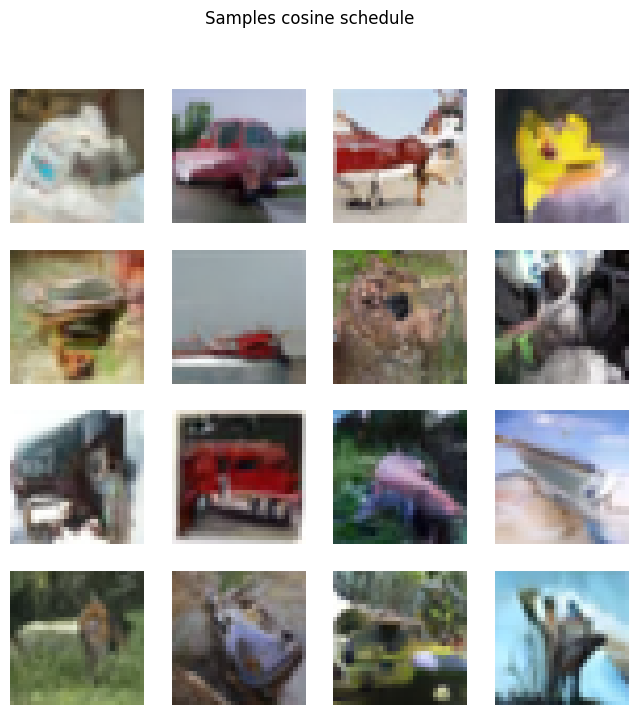

In [19]:
# ========= YOUR CODE STARTS HERE ========= #


def inference(checkpoint_path=None, schedule="cosine", cfg_scale=0.0, n=16):

    diffusion = Diffusion(T=T, schedule=schedule)
    checkpoint_path = checkpoint_path or "checkpoints/ckpt-430000.pt"
    ckpt = torch.load(checkpoint_path, map_location=device)

    model_ema = EpsModel(in_ch=channels, base_ch=128, time_dim=256,
                            num_classes=num_classes, p_uncond=0.1).to(device)

    model_ema.load_state_dict(strip_prefix(ckpt['ema']))

    x = sample(diffusion, model_ema, n=n, cfg_scale=cfg_scale)

    return x

# ========== YOUR CODE ENDS HERE ========== #

x = inference("checkpoints/ckpt-350000.pt", schedule="cosine", cfg_scale=0.0)
show_batch(x, title=f"Samples cosine schedule")

Here is list of required experiments (document every with plots/evaluation metrics/images):


A. Schedule ablation:

 - Train with linear vs cosine schedules for the same number of steps.

- Plot loss curves

- Provide samples from EMA at the end

B. CFG ablation

- With the EMA model, sample with $\text{cfg\_scale} \in \{0, 1, 3, 5\}$

- Show grids and comment on diversity vs class faithfulness.

C. Time steps ablation

- Compare sampling with $T=1000$ vs $T=250$ (train at $T=1000$, but implement accelerated sampling by skipping steps).

- Implement a function that samples using a subset of timesteps (e.g., uniform stride).

- Show quality degradation.

Comment on all the findings

### Cosine vs. Linear scheduling abalation

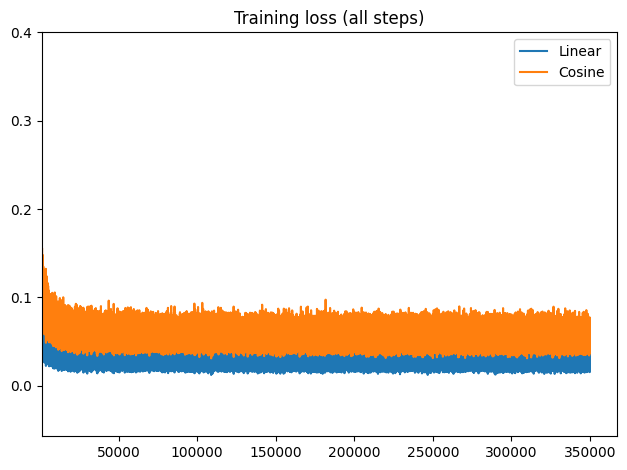

In [ ]:
linear_ckpt_path = "linear-checkpoints/ckpt-300000.pt"
cosine_ckpt_path = "checkpoints/ckpt-300000.pt"

linear_ckpt = torch.load(linear_ckpt_path, map_location=device)
cosine_ckpt = torch.load(cosine_ckpt_path, map_location=device)

linear_loss_hist = linear_ckpt['loss_hist']
cosine_loss_hist = cosine_ckpt['loss_hist']

plt.plot(linear_loss_hist, label="Linear")
plt.plot(cosine_loss_hist, label="Cosine")
plt.title("Training loss (all steps)")
plt.xlim(left=1000)
plt.ylim(top=0.4)

plt.legend()
plt.tight_layout()
plt.show()


Here it is visible that training diffusion model with cosine schedule has consistenly higher loss. It is explained by the fact that by using linear schedule sample converges to $\mathscr{N}(0, I)$ faster, meaning that model has less distinct data to learn, as on late inerations, data doesn't differ from pure noise much. While with cosine schedule noise added more gradually, meaning model has more distinct data to fit, and that's why loss is consistently bigger.

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 88.97it/s]


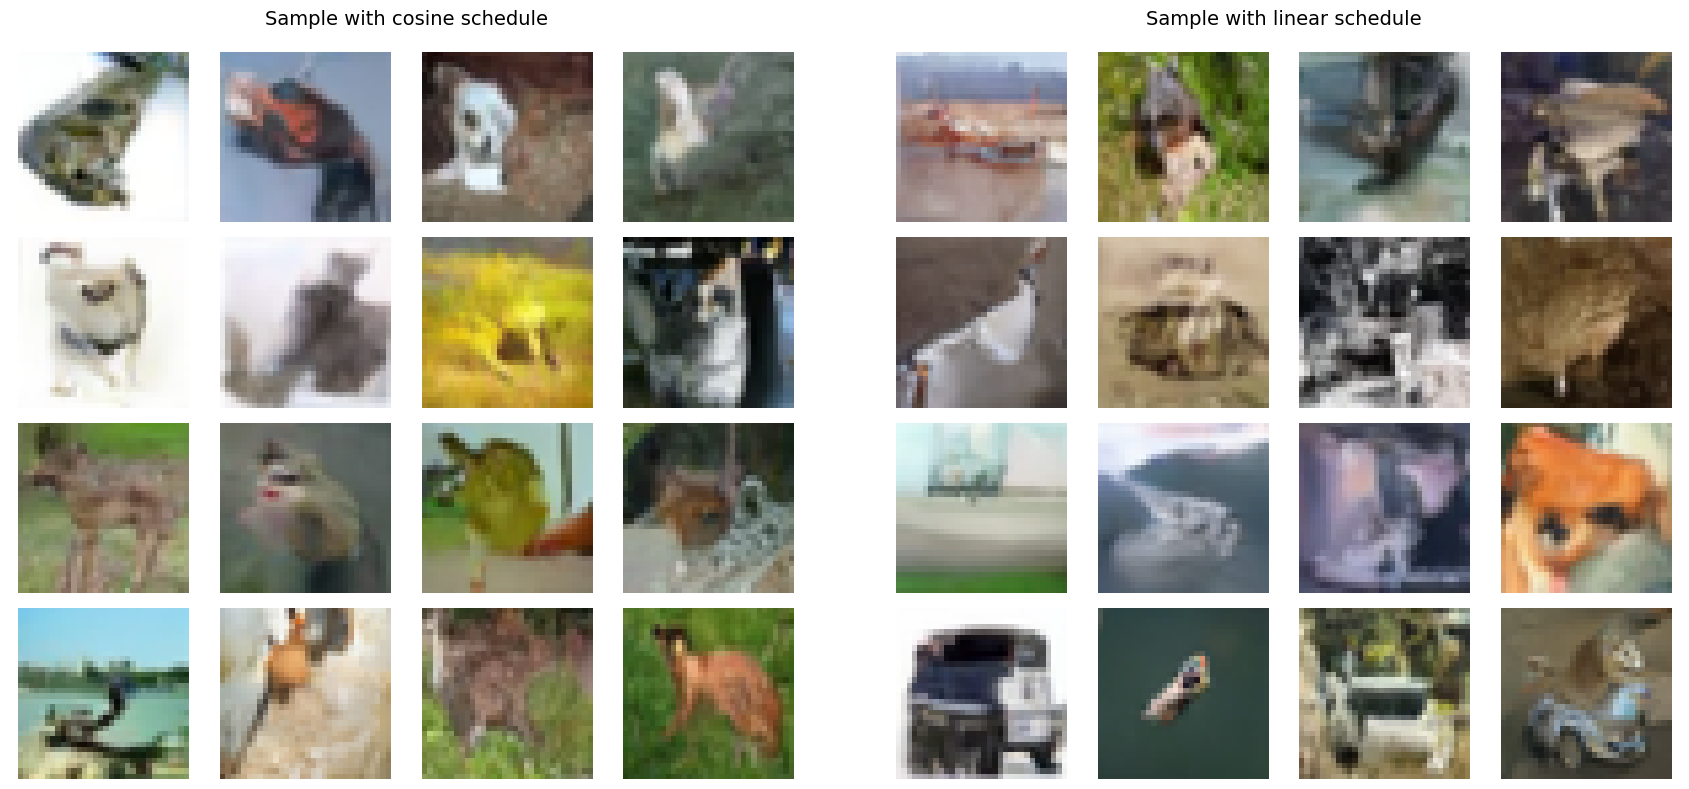

In [30]:
x_cosine = inference("checkpoints/ckpt-300000.pt", schedule="cosine", cfg_scale=0.0, n=16)
x_linear = inference("linear-checkpoints/ckpt-300000.pt", schedule="linear", cfg_scale=0.0, n=16)

show_two_batches(
    x_cosine,
    x_linear,
    n=16,
    title1="Sample with cosine schedule",
    title2="Sample with linear schedule"
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 88.66it/s]


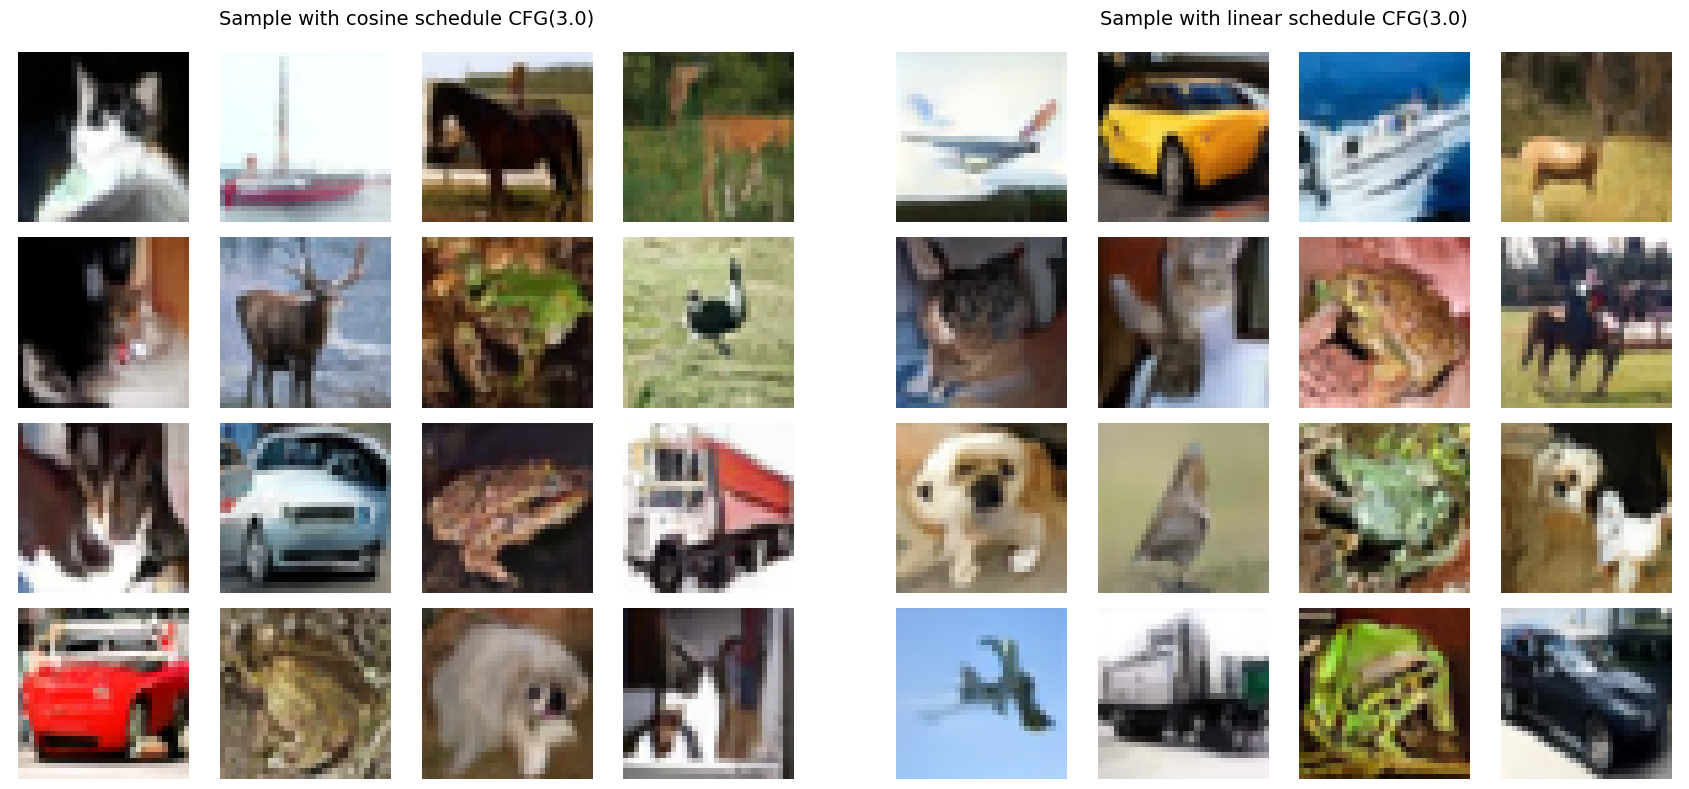

In [31]:
x_cosine = inference("checkpoints/ckpt-300000.pt", schedule="cosine", cfg_scale=3.0, n=16)
x_linear = inference("linear-checkpoints/ckpt-300000.pt", schedule="linear", cfg_scale=3.0, n=16)

show_two_batches(
    x_cosine,
    x_linear,
    n=16,
    title1="Sample with cosine schedule CFG(3.0)",
    title2="Sample with linear schedule CFG(3.0)"
)

In uncondidioned and condidionned cases, learning with cosine schedule resulted in more legible samples. 

### CFG Abalation

In [39]:
x_cosine_cfg_0 = inference("checkpoints/ckpt-300000.pt", schedule="cosine", cfg_scale=0.0, n=8)
x_cosine_cfg_1 = inference("checkpoints/ckpt-300000.pt", schedule="cosine", cfg_scale=1.0, n=8)
x_cosine_cfg_3 = inference("checkpoints/ckpt-300000.pt", schedule="cosine", cfg_scale=3.0, n=8)
x_cosine_cfg_5 = inference("checkpoints/ckpt-300000.pt", schedule="cosine", cfg_scale=5.0, n=8)

x_linear_cfg_0 = inference("linear-checkpoints/ckpt-300000.pt", schedule="linear", cfg_scale=0.0, n=8)
x_linear_cfg_1 = inference("linear-checkpoints/ckpt-300000.pt", schedule="linear", cfg_scale=1.0, n=8)
x_linear_cfg_3 = inference("linear-checkpoints/ckpt-300000.pt", schedule="linear", cfg_scale=3.0, n=8)
x_linear_cfg_5 = inference("linear-checkpoints/ckpt-300000.pt", schedule="linear", cfg_scale=5.0, n=8)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:09<00:00, 100.38it/s]


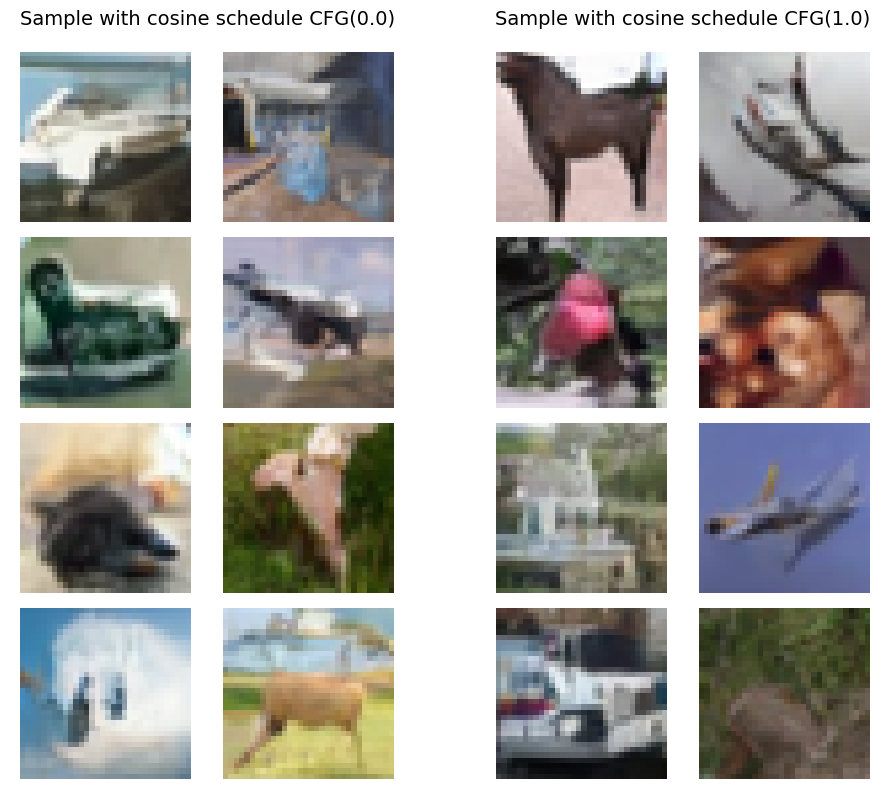

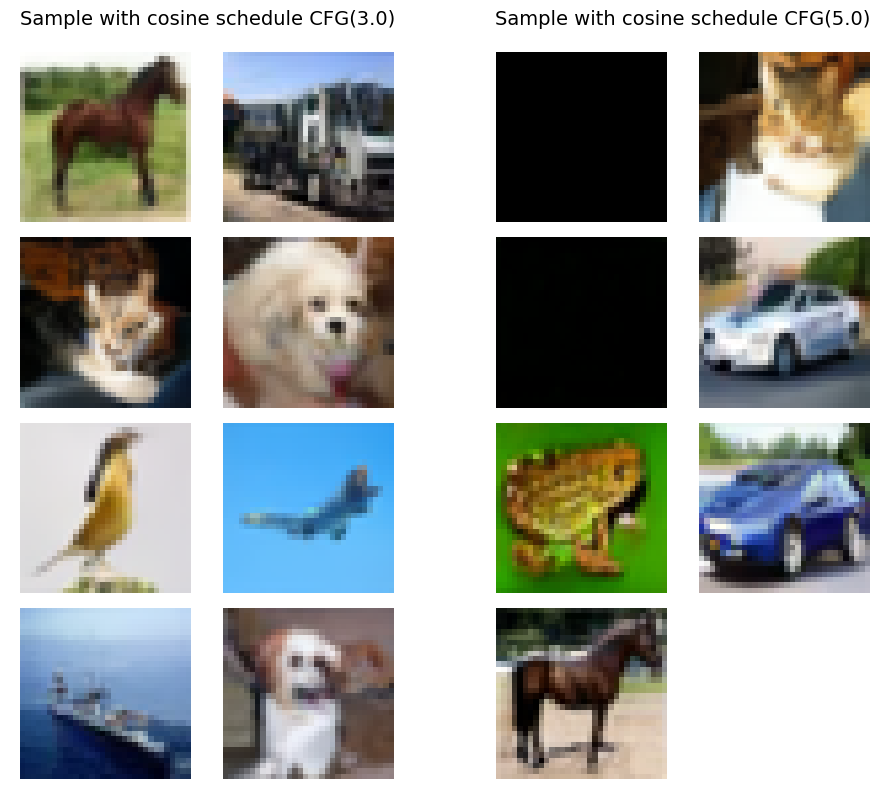

In [40]:
show_two_batches(
    x_cosine_cfg_0,
    x_cosine_cfg_1,
    n=8,
    title1="Sample with cosine schedule CFG(0.0)",
    title2="Sample with cosine schedule CFG(1.0)"
)

show_two_batches(
    x_cosine_cfg_3,
    x_cosine_cfg_5,
    n=8,
    title1="Sample with cosine schedule CFG(3.0)",
    title2="Sample with cosine schedule CFG(5.0)"
)

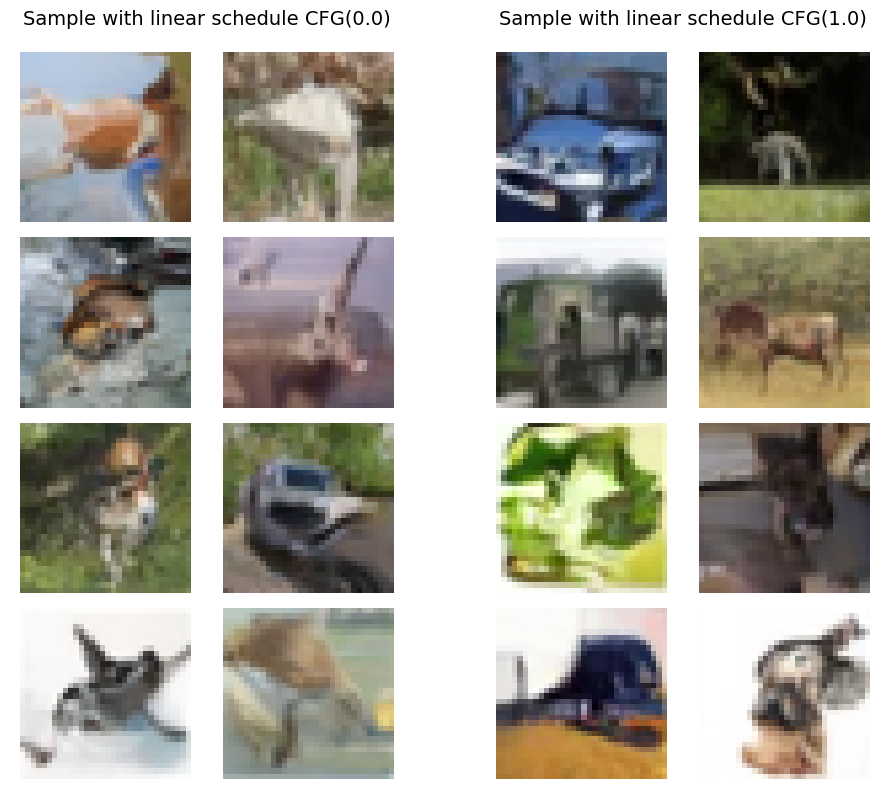

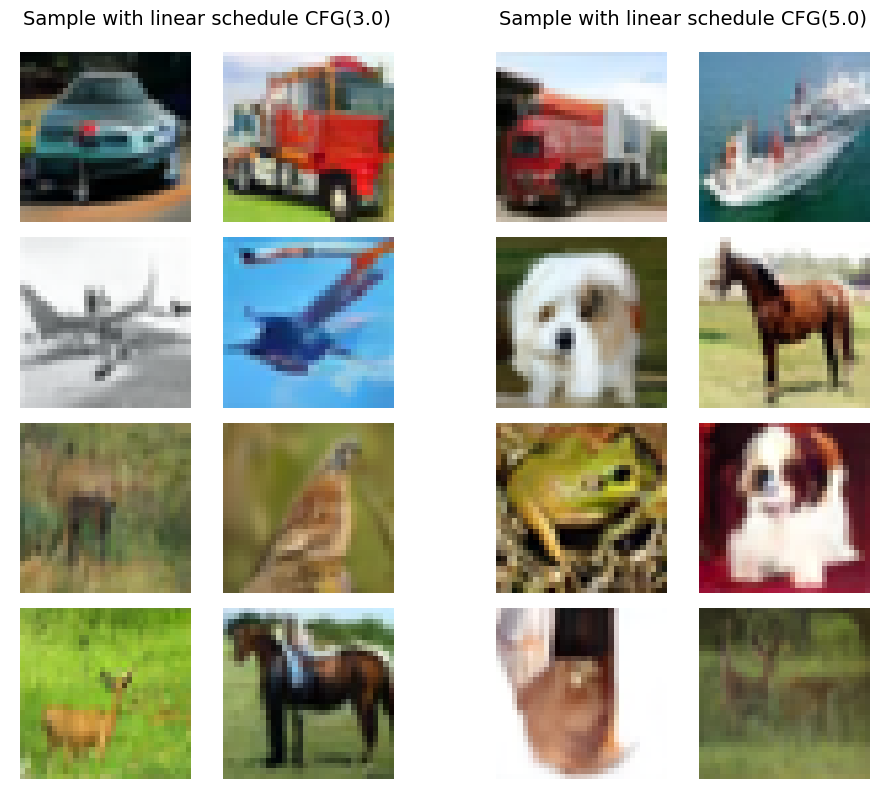

In [43]:
show_two_batches(
    x_linear_cfg_0,
    x_linear_cfg_1,
    n=8,
    title1="Sample with linear schedule CFG(0.0)",
    title2="Sample with linear schedule CFG(1.0)"
)

show_two_batches(
    x_linear_cfg_3,
    x_linear_cfg_5,
    n=8,
    title1="Sample with linear schedule CFG(3.0)",
    title2="Sample with linear schedule CFG(5.0)"
)

In cases of linear and cosine schedule in increasing CFG scale increased object clarity. (when scale is zero that most of object has very unclear outline). Also upon increasing scale diversity also increased, in terms of objects and color set.

### DDIM sampling tests

In [19]:
@torch.no_grad()
def ddim_p_sample(diffusion: Diffusion, model: EpsModel, xt, time_step: int, prev_time_step: int, y, cfg_scale=0.0):
    """
    One reverse step: x_{t-1} ~ N(mu, var)
    CFG: eps = eps_uncond + s*(eps_cond - eps_uncond)
    """
    # ========= YOUR CODE STARTS HERE ========= #
    eps_uncond = model(xt, time_step, None)
    eps_cond   = model(xt, time_step, y)
    eps = eps_uncond + cfg_scale * (eps_cond - eps_uncond)

    alpha_t = diffusion.alphas_bar[time_step]
    alpha_t_prev = diffusion.alphas_bar[prev_time_step]

    mean = torch.sqrt(alpha_t_prev / alpha_t).view(-1, 1, 1, 1)
    variance = (torch.sqrt(1 - alpha_t_prev) - torch.sqrt(
                    (alpha_t_prev * (1 - alpha_t)) / alpha_t)).view(-1, 1, 1, 1)

    mean = mean * xt
    variance = variance

    return mean + variance * eps
    # ========== YOUR CODE ENDS HERE ========== #


@torch.no_grad()
def ddim_sample(diffusion, model, n, steps=1, y=None, cfg_scale=0.0):
    model.eval()
    a = diffusion.T // steps
    time_steps = np.asarray(list(range(0, diffusion.T, a)))

    time_steps = time_steps + 1
    time_steps_prev = np.concatenate([[0], time_steps[:-1]])

    if y is None:
        y = torch.randint(0, num_classes, (n,), device=device)

    x_t = torch.randn(n, channels, image_size, image_size, device=device)

    for step in tqdm(reversed(range(steps)), total=diffusion.T):
        t = torch.full((n,), time_steps[step], device=device, dtype=torch.long)
        t_prev = torch.full((n,), time_steps_prev[step], device=device, dtype=torch.long)
        x_t = ddim_p_sample(diffusion, model, x_t, t, t_prev, y, cfg_scale)

    return torch.clamp(x_t, -1, 1)  


def ddim_inference(checkpoint_path=None, schedule="cosine", steps=1, cfg_scale=0.0, n=16):

    diffusion = Diffusion(T=T, schedule=schedule)
    checkpoint_path = checkpoint_path or "checkpoints/ckpt-430000.pt"
    ckpt = torch.load(checkpoint_path, map_location=device)

    model_ema = EpsModel(in_ch=channels, base_ch=128, time_dim=256,
                            num_classes=num_classes, p_uncond=0.1).to(device)

    model_ema.load_state_dict(strip_prefix(ckpt['ema']))

    x = ddim_sample(diffusion, model_ema, n=n, cfg_scale=cfg_scale, steps=steps)

    return x



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 999/1000 [00:10<00:00, 97.98it/s]


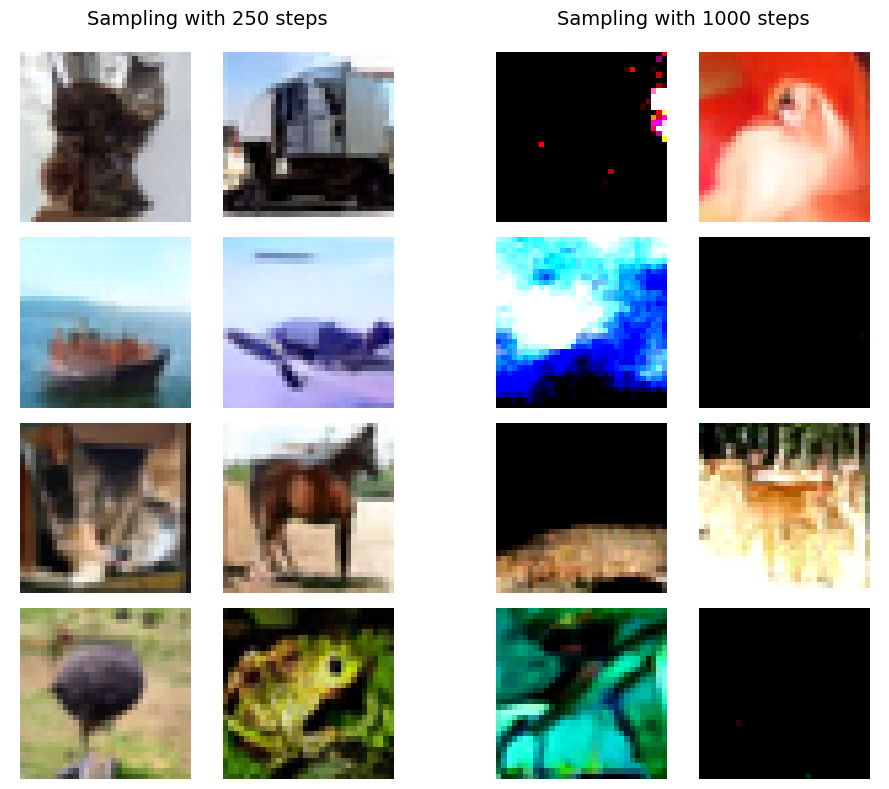

In [20]:
x_250 = ddim_inference("checkpoints/ckpt-350000.pt", "cosine", steps=250, cfg_scale=3.0, n=8)
x_1000 = ddim_inference("checkpoints/ckpt-350000.pt", "cosine", steps=999, cfg_scale=3.0, n=8)

show_two_batches(
    x_250,
    x_1000,
    n=8,
    title1="Sampling with 250 steps",
    title2="Sampling with 1000 steps"
)


As visible on plots DDIM works better with smaller number of samples, as it's objective in refinements over large gaps of noise and sampling doesn't adds noise on each step (like DDPM standard sampling do). As original network was trained in DDPM training style (small additions on noise), then DDIM sampling with smaller number of steps works better.

Questions:

1. Cosine vs linear schedule: what changes visually and why?

2. How does CFG trade off sample diversity vs conditional fidelity?

3. Does EMA always help? When can it hurt?

4. What happens when you stride timesteps? Give a hypothesis tied to the reverse-process approximation.

___
1. Cosine schedule produces more images with clear objects than linear schedule do. The reason for this improvement is that $\overline{\alpha_t}$ for cosine schedule decreases slower at the start, that gives an opportunity for UNet to learn noise prediction.
2. Basically condition scale leverages sample diversity vs conditional fidelity.
3. EMA helps, when prediction of gradient(s) are very noisy, so using it we can add "momentum" taken as previous estimate, to propagate in steady direction. Otherwise, EMA can be actually bad, when for example we only start training, and we have a high weights for previous estimate. In such a way optimization step can overthrow a location of minimum.
4. When striding timestemps, we basically estimating not the noise added on one step, but, over $n$ steps of diffusion. Also our hypothesis that this sampling can be fully deterministic. (As on sampling we don't add noise)
___

## 3. GANs and VAEs **(3.5 pt + up to 1.5 additional)**

### 3.1 Generative Adversarial Networks (GANs) (0.5 pt)

GANs is a very interesting and powerful approach to the generative modelling. In the GANs paradigm, we learn data distribution $p_\text{data}$ implicitly - via an adversarial training between two networks: Generator $G$ and Discriminator $D$. We aim to make generator distribution $p_g$ a good approximation to the data distribution $p_\text{data}$. The generator distribution is learned as mapping from some simple prior distribution $p(z)$ to the data. Later, our Discriminator takes as input true samples (from $p_\text{data}$) and generated samples (from $p_g$) and tries to differentiate between them. As output of our Discriminator, we expect to see the probability of sample being from the data distribution ($p_\text{data}$). Discriminator tries to correctly guess whether samples is true or fake, and Generator tries to fool the Discriminator by creating realistic samples.

More formally, $D$ and $G$ play the following two-player minimax game with value function $V(G, D)$:

$$
\min_G \max_D V(G, D) = \mathbb{E}_{x \sim p_\text{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p(z)}[\log(1 - D(G(z)))]
$$

In this section, we'll analyze why $p_g = p_\text{data}$ is the global optimum of the objective above (which is good, as that's what we want our generator to learn.)

#### Optimal discriminator **(0.25 pt)**

Rigorously prove that for fixed $G$ optimal discriminator $D$ is:

$$
D_G^*(x) = \frac{p_\text{data}(x)}{p_\text{data}(x) + p_g(x)}.
$$

Note that when we have optimal discriminator $D_G^*(x)$, the objective for generator $C(G)$ can be defined as follows:

$$
\begin{align*}
C(G) = \max_D V(G, D) &= \mathbb{E}_{x \sim p_\text{data}(x)}[\log D_G^*(x)] + \mathbb{E}_{\color{cyan}{z \sim p_Z(z)}}[\log(1 - D_G^*(G(z)))] = \\
&= \mathbb{E}_{x \sim p_\text{data}(x)}[\log D_G^*(x)] + \mathbb{E}_{\color{cyan}{x \sim p_g(x)}}[\log(1 - D_G^*(x))].
\end{align*}
$$

___
[ Answer here. ]
___


#### Optimal generator **(0.25 pt)**

Prove that the global minimum of the generator objective $C(G)$ (when we have optimal discriminator) is achieved if and only if $p_g = p_\text{data}$.

Show that then $C(G)$ achieves value of $-\log 4$.

You may use Jensen–Shannon divergence.

___
[ Answer here. ]
___

### 3.2 Variational Autoencoders (VAEs) **(3 pt + up to 1.5 additional)**

Variational AutoEncoder (VAE) is a specific type of Latent Variable Model (LVM). In LVM paradigm, we assume that our data $\mathbf x$ can be modelled via some hidden (unobserved) and semantically meaningful variables $\mathbf z_i$. VAE is defined in the following way:

* latent vector $\mathbf z \in \mathbb R^d$ has a standard normal prior $p(\mathbf z) = \mathcal{N}(\mathbf 0, I_d)$;
* an approximate (i.e., variational) posterior (an encoder) $q_{\phi}(\mathbf z \mid \mathbf x) = \mathcal{N}(\mu_{\phi}(\mathbf x), \Sigma_{\phi}(\mathbf x))$ with a diagonal covariance matrix;
* a reconstruction likelihood (a decoder) $p_{\theta}(\mathbf x \mid \mathbf z)$, typically an isotropic Gaussian.

#### 3.2.1 VAEs on 2D data **(1.75 pt)**


In this part, you will train a simple VAE on 2D samples.

Firstly, let's generate and visualize our data:

In [ ]:
def sample_2d_data(count: int) -> np.ndarray:
    rand = np.random.RandomState(0)
    samples = [[1.0, 2.0]] + (rand.randn(count, 2) * [[5.0, 1.0]]).dot(
        [[np.sqrt(2) / 2, np.sqrt(2) / 2], [-np.sqrt(2) / 2, np.sqrt(2) / 2]])
    return samples.astype(np.float32)


train_data, test_data = sample_2d_data(10000), sample_2d_data(2500)

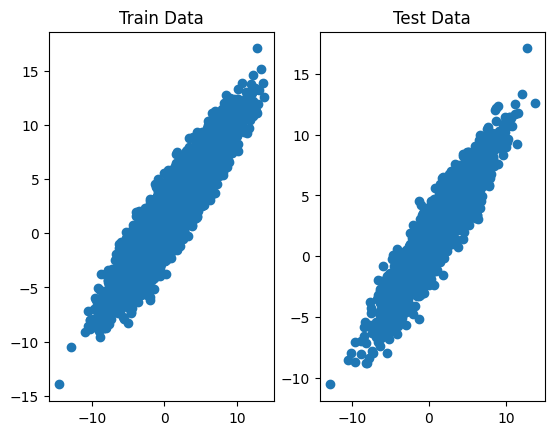

In [ ]:
def visualize_2d_data(train_data: np.ndarray, test_data: np.ndarray):
    _, (ax1, ax2) = plt.subplots(1, 2)
    ax1.set_title('Train Data')
    ax1.scatter(train_data[:, 0], train_data[:, 1])
    ax2.set_title('Test Data')
    ax2.scatter(test_data[:, 0], test_data[:, 1])
    plt.show()


visualize_2d_data(train_data, test_data)

##### VAE Encoder and Decoder **(0.25 pt)**

___
Implement VAE's Encoder and Decoder. The recommended architecture is the following:

```text
linear(in_dim, out_dim)
relu()

Encoder
    linear(2, 128)
    relu()
    linear(128, 128)
    relu()
    linear(128, 2*d) # d - for mu and d - for Sigma.

Decoder
    linear(d, 128)
    relu()
    linear(128, 128)
    relu()
    linear(128, 2*2) # 2 for reconstruction mean, and 2 for reconstruction variance.
```
This task uses $d = \text{dim}(z)=2$ for easy visualizations.
___

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dimensions: list[int], d: int):
        super().__init__()
        # ========= YOUR CODE STARTS HERE ========= #

        # ========== YOUR CODE ENDS HERE ========== #

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Returns latent parameters as 2d vector.
        First `d` values correspond to the mean, the rest -- log of variance.
        """
        # ========= YOUR CODE STARTS HERE ========= #

        z_params = ...
        # ========== YOUR CODE ENDS HERE ========== #
        return z_params


class Decoder(nn.Module):
    def __init__(self, d: int, hidden_dimensions: list[int], output_dim: int):
        super().__init__()
        # ========= YOUR CODE STARTS HERE ========= #

        # ========== YOUR CODE ENDS HERE ========== #

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Returns a reconstruction from a latent vector.
        """
        # ========= YOUR CODE STARTS HERE ========= #

        # ========== YOUR CODE ENDS HERE ========== #
        return ...

#####  KL-divergence between 2 Gaussian Distributions **(0.25 pt)**

Recall that KL-divergence between 2 arbitratry distributions $p$ and $q$ is defined as follows:

$$
D_{KL}(p \parallel q) = \mathbb{E}_{\mathbf x \sim p(\mathbf x)} [\log \frac{p(\mathbf x)}{q(\mathbf x)}]
$$


Derive the formula for KL-divergence for Multivariate Gaussians $p$ and $q$ (where $p = \mathcal{N}(\mu_p, \Sigma_p)$ and $q = \mathcal{N}(\mu_q, \Sigma_q)$) in $d$ dimensions.

Simplify the formula when $q$ is a standard Gaussian (i.e., $q = \mathcal{N}(\mathbf 0, I_d)$.)

**Hint:** For $\mathbf x \sim \mathcal{N}(\mu, \Sigma)$ and any matrix $A$, the following identity holds:
$$
\mathbb{E}\big[\mathbf x^\top A \mathbf x\big] = \mu^\top A\mu + \operatorname{trace}(A\Sigma).
$$

___
[ Answer here.]
___

##### VAE implementation **(0.75 pt)**

Implement the code for VAE below:

* Decoder's output vector is of dimension $2\cdot\text{input\_dim}$, as we predict both $\mu$ and $\Sigma = \operatorname{diag}(\sigma^2_1, \dots, \sigma^2_{\text{input\_dim}})$ of the reconstruction.
* Predicted variances $\sigma^2_i$ are positive, thus we can predict their logarithm for better convergence. We can always exponentiate them when necessary.
* In this task, our `Decoder` produces the parameters of a Gaussian distribution, from which we should sample our data point $\mathbf {\hat x}$ (or calculate its density for the reconstruction loss computation.)
* When computing reconstruction loss and KL loss, **average** over the batch dimension and **sum** over the feature dimension.

Training loss is defined as negative Evidence Lower Bound (ELBO):

$$
\text{ELBO} = \mathbb{E}_{\mathbf z \sim q_{\phi}(\mathbf z \mid \mathbf x)} \big [ \log p_{\theta}(\mathbf x \mid \mathbf z)\big ] - D_{\text{KL}}(q_{\phi}(\mathbf z \mid \mathbf x) \parallel p(\mathbf z)).
$$

In [ ]:
@dataclass
class LossMetadata:
    total_loss: torch.Tensor
    reconstruction_loss: torch.Tensor
    KL_loss: torch.Tensor


class VAEAbstract(nn.Module, ABC):
    @abstractmethod
    def loss(self, x: torch.Tensor) -> LossMetadata:
        """
        Calculates total loss (training objective) as sum of reconstruction and KL divergence losses.
        """
        pass

    @abstractmethod
    def sample(self, n: int) -> tuple[np.ndarray, np.ndarray]:
        """
        Samples `n` hidden variables from the prior p(z) and returns reconstructions.
        Reconstructions may need to be sampled.
        @:returns [z, x]
        """
        pass


In [ ]:
class FullyConnectedVAE(VAEAbstract):
    def __init__(self, input_dim: int, d: int, encoder_hidden_dimensions: list[int],
                 decoder_hidden_dimensions: list[int]):
        super().__init__()
        # ========= YOUR CODE STARTS HERE ========= #

        # ========== YOUR CODE ENDS HERE ========== #

    def reconstruction_loss(self, x: torch.Tensor, mu_x: torch.Tensor, log_variance_x: torch.Tensor) -> torch.Tensor:
        """
        Computes reconstruction loss as negative log of (conditional) likelihood of x.
        `mu_x` and `log_variance_x` have been produced by a decoder for given `x`.
        """
        # ========= YOUR CODE STARTS HERE ========= #

        reconstruction_loss = ...
        # ========== YOUR CODE ENDS HERE ========== #
        return reconstruction_loss

    def KL_loss(self, mu_z: torch.Tensor, log_variance_z: torch.Tensor) -> torch.Tensor:
        """
        Computes KL divergence between approximate posterior N(mu_z, Sigma_z) and prior N(0, I).
        """
        # ========= YOUR CODE STARTS HERE ========= #
        KL_loss = ...
        # ========== YOUR CODE ENDS HERE ========== #
        return KL_loss

    @override
    def loss(self, x: torch.Tensor) -> LossMetadata:
        """
        Calculates total loss (training objective) as sum of reconstruction and KL divergence losses.
        """
        # ========= YOUR CODE STARTS HERE ========= #
        KL_loss = ...

        reconstruction_loss = ...

        total_loss = ...
        # ========== YOUR CODE ENDS HERE ========== #
        return LossMetadata(
            total_loss=total_loss,
            reconstruction_loss=reconstruction_loss,
            KL_loss=KL_loss
        )

    @override
    def sample(self, n: int) -> tuple[np.ndarray, np.ndarray]:
        """
        Samples `n` hidden variables from the prior and returns reconstructions.
        Reconstructions also have to be sampled.
        @:returns [z, x]
        """
        # ========= YOUR CODE STARTS HERE ========= #
        z = ...

        x = ...
        # ========== YOUR CODE ENDS HERE ========== #
        return z, x

##### VAE training **(0.25 pt)**

___
[ Train VAE on the generated data. Implement 2 functions below. ]
___

**Note**: `train` function implements simple KL annealing. The idea behind it is to not pay attention to KL divergence during first training stages to prevent posterior collapse.

In [ ]:
def train_one_epoch(model: VAEAbstract, train_loader: DataLoader, optimizer: Optimizer, KL_weight: float) -> list[LossMetadata]:
    """
    Trains VAE for one epoch.
    `KL_weight` is the weight of the KL loss to be used. Is denoted `beta` in beta-VAEs.
    Returns loss metadata for each mini-batch.
    """
    model.train()
    losses: list[LossMetadata] = []
    # ========= YOUR CODE STARTS HERE ========= #

    # ========== YOUR CODE ENDS HERE ========== #
    return losses


def evaluate(model: VAEAbstract, data_loader: DataLoader) -> LossMetadata:
    """
    Evaluates VAE. Could be used after every training epoch.
    Returns average loss over whole val/test set.
    """
    model.eval()
    avg_losses = LossMetadata(
        *(torch.tensor(0.0, device=next(model.parameters()).device)) for _ in range(3)
    )
    with torch.no_grad():
    # ========= YOUR CODE STARTS HERE ========= #
        ...
    # ========== YOUR CODE ENDS HERE ========== #
    return avg_losses


def train(model: VAEAbstract, train_loader: DataLoader, test_loader: DataLoader, epochs: int, warmup_epochs: int, lr: float, writer: SummaryWriter) -> None:
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        print(f"EPOCH {epoch} started")

        train_losses = train_one_epoch(model, train_loader, optimizer, KL_weight=min(1.0, (epoch - 1) / warmup_epochs))

        for i, loss in enumerate(train_losses):
            stage = epoch * len(train_loader) + i
            writer.add_scalar('Loss/train/total', loss.total_loss.item(), stage)
            writer.add_scalar('Loss/train/reconstruction', loss.reconstruction_loss.item(), stage)
            writer.add_scalar('Loss/train/KL', loss.KL_loss.item(), stage)

        test_loss = evaluate(model, test_loader)
        writer.add_scalar('Loss/test/total', test_loss.total_loss.item(), epoch)
        writer.add_scalar('Loss/test/reconstruction', test_loss.reconstruction_loss.item(), epoch)
        writer.add_scalar('Loss/test/KL', test_loss.KL_loss.item(), epoch)

        writer.flush()


SyntaxError: iterable unpacking cannot be used in comprehension (47012901.py, line 22)

Training routine:

In [ ]:
device = {
    hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): "mps",
    torch.cuda.is_available(): "cuda",
}.get(True, "cpu")
print(f"Using device `{device}`.")

In [ ]:
model = FullyConnectedVAE(input_dim=2, d=2, encoder_hidden_dimensions=[128, 128], decoder_hidden_dimensions=[128, 128])
model.to(device)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

writer = SummaryWriter(log_dir="runs/2D_experiment")

train(model, train_loader, test_loader, epochs=5, warmup_epochs=0, lr=0.01, writer=writer)

**`tensorboard`** library allows to easily explore the training dynamics.

You can run it:
- from the terminal: `python -m tensorboard.main --logdir=runs`
- embed into the notebook with:
    ```python
    %load_ext tensorboard
    %tensorboard --logdir=runs
    ```

Provide loss plots from the training phase.

##### VAE Sampling **(0.25 pt)**

___
[ Sample 1000 values using your VAE model. Visualize both latent and generated variables. Compare distribution of generated values with data distribution. Comment on your results. ]
___

In [ ]:
# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #

#### 3.2.2 VAEs on Images **(1.25 pt)**


##### Data loading

In this question, you will train CNN (Convolutional Neural Network) version of VAE on image dataset (SVHN) and analyze its properties.

Please download dataset from [here](https://drive.google.com/drive/folders/1ICMh3Zz2hG23WcrjYANRk14Iqm8lC0I9?usp=sharing).

Firstly, let's load and visualize our data:

In [ ]:
def load_image_data(fname: str) -> Tuple[np.ndarray, np.ndarray]:
    with open(fname, 'rb') as f:
        data = pickle.load(f)

    train_data, test_data = data['train'], data['test']
    if 'mnist.pkl' in fname or 'shapes.pkl' in fname:
        train_data = (train_data > 127.5).astype('uint8')
        test_data = (test_data > 127.5).astype('uint8')
    return train_data, test_data


train_data, test_data = load_image_data("data/svhn.pkl")

In [ ]:
normalized_train_data = (np.transpose(train_data, (0, 3, 1, 2)) / 255.).astype('float32')
normalized_test_data = (np.transpose(test_data, (0, 3, 1, 2)) / 255.).astype('float32')

print(normalized_train_data.shape)

In [ ]:
def visualize_images(images: np.ndarray):
    images = (torch.FloatTensor(images) / 255).permute(0, 3, 1, 2)
    grid_img = make_grid(images, nrow=10)
    plt.figure()
    plt.title("Images")
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.axis('off')
    plt.show()


def visualize_image_dataset(data: np.ndarray):
    idxs = np.random.choice(len(data), replace=False, size=(100,))
    images = data[idxs]
    visualize_images(images)


visualize_image_dataset(train_data)

##### CNN VAE Architecture **(0.75 pt)**

Implement CNN VAE. Our latent vector's $\mathbf z$ dimensionality here will be $d=16$. For a decoder $p_{\theta}(\mathbf x \mid \mathbf z) = \mathcal{N}(\mu_{\theta}(\mathbf z), \Sigma_{\theta}(\mathbf z))$ we will assume an isotropic covariance $\Sigma_{\theta}(\mathbf z) \propto I$ (we are not learning covariance of the decoder).

The recommended architecture is following:

```
conv2d(in_channels, out_channels, kernel_size, stride, padding)
transpose_conv2d(in_channels, out_channels, kernel_size, stride, padding)
linear(in_dim, out_dim)
relu()
leaky_relu(negative_slope)
residual_block(channels) = identity + (conv2d(channels, channels, 3, 1, 1) * leaky_relu(0.2))  # implement it yourself. `*` denotes function composition.
flatten()
sigmoid()


Encoder
    conv2d(3, 32, 3, 1, 1)
    leaky_relu(0.2)
    residual_block(32)

    conv2d(32, 64, 3, 2, 1)   # feature map with spatial dimensions 16 x 16
    leaky_relu(0.2)
    residual_block(64)

    conv2d(64, 128, 3, 2, 1)  # feature map with spatial dimensions 8 x 8
    leaky_relu(0.2)
    residual_block(128)

    conv2d(128, 256, 3, 2, 1) # feature map with spatial dimensions 4 x 4
    leaky_relu(0.2)
    residual_block(256)

    flatten()
    linear(4 * 4 * 256, 2 * d) # outputs: mu and log_variance (`d` each)


Decoder
    linear(d, 4 * 4 * 128)
    relu()
    reshape(128, 4, 4)

    transpose_conv2d(128, 128, 4, 2, 1) # feature map with spatial dimensions 8 x 8
    relu()

    transpose_conv2d(128, 64, 4, 2, 1)  # feature map with spatial dimensions 16 x 16
    relu()

    transpose_conv2d(64, 32, 4, 2, 1)   # feature map with spatial dimensions 32 x 32
    relu()

    conv2d(32, 3, 3, 1, 1)
    sigmoid()  # maps outputs to [0, 1].
```

*   when computing reconstruction loss, it suffices to compute MSE between the reconstructed datapoint $\mathbf {\hat x}$ and true $\mathbf x$. Do not forget to perform summation over pixels(or features in KL) and averaging over batch dimension!

Architecture comments:
- `sigmoid` must be used to ensure reconstructed pixels lie in the [0, 1] range.
- Residual blocks enrich the features while preserving the feature map's size.
- Encoder is more expressive (complex) that decoder. Think about why such design choice was made.
- Leaky ReLU's mitigate the problem of dying neurons.

In [ ]:
class ConvEncoder(nn.Module):
    def __init__(self, input_shape: Tuple[int, int, int], latent_dimensionality: int):
        super().__init__()
        # ========= YOUR CODE STARTS HERE ========= #

        # ========== YOUR CODE ENDS HERE ========== #

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # ========= YOUR CODE STARTS HERE ========= #

        mu, log_variance = ...
        # ========== YOUR CODE ENDS HERE ========== #
        return mu, log_variance


class ConvDecoder(nn.Module):
    def __init__(self, latent_dimensionality: int, output_shape: Tuple[int, int, int]):
        super().__init__()
        # ========= YOUR CODE STARTS HERE ========= #

        # ========== YOUR CODE ENDS HERE ========== #

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # ========= YOUR CODE STARTS HERE ========= #

        output = ...
        # ========== YOUR CODE ENDS HERE ========== #
        return output

In [ ]:
class ConvVAE(VAEAbstract):
    def __init__(self, input_shape: Tuple[int, int, int], latent_dimensionality: int):
        super().__init__()
        assert len(input_shape) == 3
        # ========= YOUR CODE STARTS HERE ========= #

        # ========== YOUR CODE ENDS HERE ========== #

    def reconstruction_loss(self, x: torch.Tensor, x_recon: torch.Tensor) -> torch.Tensor:
        """
        Computes reconstruction loss as MSE between `x` and `x_recon`.
        """
        # ========= YOUR CODE STARTS HERE ========= #
        reconstruction_loss = ...
        # ========== YOUR CODE ENDS HERE ========== #
        return reconstruction_loss

    def KL_loss(self, mu: torch.Tensor, log_variance: torch.Tensor) -> torch.Tensor:
        """
        Computes loss with KL divergence between approximate posterior N(mu, Sigma) and prior N(0, I).
        """
        # ========= YOUR CODE STARTS HERE ========= #
        KL_loss = ...
        # ========== YOUR CODE ENDS HERE ========== #
        return KL_loss

    @override
    def loss(self, x: torch.Tensor) -> LossMetadata:
        """
        Calculates loss as sum of reconstruction and KL divergence losses.
        """
        # ========= YOUR CODE STARTS HERE ========= #

        # ========== YOUR CODE ENDS HERE ========== #
        return ...

    @override
    def sample(self, n: int) -> list[np.ndarray]:
        """
        Samples from prior and returns generated samples.
        """
        # ========= YOUR CODE STARTS HERE ========= #
        ...
        # ========== YOUR CODE ENDS HERE ========== #

##### CNN VAE training

Train CNN VAE on the images.

*Note*: on Macbook M1 Pro's GPU training took $\approx$ 90 seconds with `mps` backend, while CPU could've taken about 20 minutes. If you want faster training, you can train the model in colab with GPU ([.cuda()](https://pytorch.org/docs/stable/generated/torch.Tensor.cuda.html#torch.Tensor.cuda).)


In [ ]:
conv_VAE_model = ConvVAE((3, 32, 32), 16)
conv_VAE_model.to(device)

train_loader = DataLoader(normalized_train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(normalized_test_data, batch_size=128)

writer = SummaryWriter(log_dir="runs/digits_experiment")

train(conv_VAE_model, train_loader, test_loader, epochs=20, warmup_epochs=10, lr=1e-4, writer=writer)

Share your training plots.

##### CNN VAE Sampling **(0.25 pt)**


Sample 100 images using a trained CNN VAE model. Visualize them.

In [ ]:
# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #

##### CNN VAE Interpolation **(0.25 pt)**

Take 10 image pairs ($I_1, I_2$) (20 images in total) from the test dataset. Convert them to latent codes ($\mathbf z_1, \mathbf z_2$) via VAE Encoder.

For each pair, calculate 10 interpolations (including $\mathbf z_1$ and $\mathbf z_2$) of latent codes, which are distributed uniformly along the $\mathbf z_1 \rightarrow \mathbf z_2$ line. Decode these interpolations and visualize them. Explain results.

In [ ]:
# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #

#### 3.2.3 Additional. Importance Weighted AE + VAE-GAN **(up to 1.5 pt)**

This section builds upon a previous task, and tries to improve performance on the same data.

*Importance weighted Autoencoders (IWAEs)* are similar to VAEs, however, they provide a tighter bound to the data log-likelihood.
IWAEs use $K > 1$ importance-weighted samples $\mathbf z \sim q_\phi(\mathbf z \mid \mathbf x)$ instead of $1$ to get a better estimate of $\log p(\mathbf x)$:

$$
\mathcal L_\text{IWAE} = \mathbb E_{\mathbf z_{1:K}\sim q_\phi(\mathbf z \mid \mathbf x)}\big[\log (\frac{1}{K}\sum_{k=1}^K \frac{p(\mathbf x, \mathbf z_k)}{q_\phi(\mathbf z_k \mid \mathbf x)}) \big].
$$
When $K=1$, this reduces to VAE's objective.
Rigorously prove that IWAE's bound is tighter than VAE's. Note that IWAE's objective differs from simply estimating reconstruction quality with more samples. The objective itself also changes.

**Correct implementation of IWAE and requested proof will bring up to 1 point.**


Somewhat poor VAE's reconstruction quality could be mitigated with an adversarial loss via a discriminator network $D$.

Propose an architecture for such a discriminator, and adjust the reconstruction loss accordingly.

**Correct implementation of discriminator will bring up to 0.5 points.**

If you choose to implement both IWAE and VAE-GAN, combine them in one task. However, perform proper ablation studies (comparisons) to quantify effect of each component.

Do not forget to compare the proposed model with VAE from the previous task!

## Summary **(0.25 pt)**

Summarize in a few sentences what you have learned and achieved by completing the tasks of this lab. Comment on how it can be improved in the future. What was new and valuable for you?

___
[ Answer here. ]
___